In [2]:
import cdsapi

client = cdsapi.Client()

# 数据集名称：ERA5单层数据
dataset = "reanalysis-era5-single-levels"

# 请求参数
request = {
    "product_type": "reanalysis",
    "variable": [
        "2m_temperature",           # 地表2米气温
        "geopotential"              # 位势（用于计算500 hPa位势高度）
    ],
    "year": "2022",
    "month": ["06", "07", "08"],    # 夏季三个月
    "day": [f'{d:02d}' for d in range(1, 32)], # f"{d:02d}" for d in range(1, 32)
    "time": ["00:00", "06:00", "12:00", "18:00"],  # 每日4个时次
    "area": [50, 80, 20, 130],      # [北纬, 西经, 南纬, 东经] → 中国区域
    "format": "netcdf"              # 输出NetCDF格式
}

# 执行下载
client.retrieve(dataset, request, "china_summer_2022.nc")
print("下载完成！")

2026-07-25 17:10:21,491 INFO Request ID is c31122be-ffe3-4494-a113-b6980b42abfb
2026-07-25 17:10:21,909 INFO status has been updated to accepted
2026-07-25 17:10:38,960 INFO status has been updated to running
2026-07-25 17:10:48,560 INFO status has been updated to successful


2f436f283d70d811438233b13b58de98.nc:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

下载完成！


In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 读取NetCDF文件
ds = xr.open_dataset("china_summer_2022.nc")

# 查看数据结构
print(ds)
print(ds.data_vars)

# 查看变量信息
print(ds['t2m'])        # 2米气温（单位：K）
print(ds['z'])          # 位势（单位：m²/s²）

<xarray.Dataset> Size: 72MB
Dimensions:     (valid_time: 368, latitude: 121, longitude: 201)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2022-06-01 ... 2022-08-31T18:...
    expver      (valid_time) <U4 6kB ...
  * latitude    (latitude) float64 968B 50.0 49.75 49.5 ... 20.5 20.25 20.0
  * longitude   (longitude) float64 2kB 80.0 80.25 80.5 ... 129.5 129.8 130.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 36MB ...
    z           (valid_time, latitude, longitude) float32 36MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-25T04:56 GRIB to CDM+CF via cfgrib-0.9.1...
Data variables:
    t2m      (valid_time, latitude, longitude) float32 36MB ...
    z

In [4]:
print(ds.data_vars)

Data variables:
    t2m      (valid_time, latitude, longitude) float32 36MB ...
    z        (valid_time, latitude, longitude) float32 36MB ...


In [5]:
# 按日期分组，计算日平均（去掉00/06/12/18时次的日内变化）
ds_daily = ds.resample(valid_time='1D').mean()
t2m_daily = ds_daily['t2m'] - 273.15  # 转换为摄氏度

In [6]:
# 整个夏季（6-8月）的平均气温和位势高度
summer_mean = ds_daily.mean(dim='valid_time')
t2m_summer_mean = summer_mean['t2m'] - 273.15
z500_summer_mean = summer_mean['z'] / 98.0665

In [7]:
print(summer_mean)

<xarray.Dataset> Size: 197kB
Dimensions:    (latitude: 121, longitude: 201)
Coordinates:
  * latitude   (latitude) float64 968B 50.0 49.75 49.5 49.25 ... 20.5 20.25 20.0
  * longitude  (longitude) float64 2kB 80.0 80.25 80.5 ... 129.5 129.8 130.0
    number     int64 8B 0
Data variables:
    t2m        (latitude, longitude) float32 97kB 294.0 294.1 ... 301.4 301.4
    z          (latitude, longitude) float32 97kB 3.417e+03 3.334e+03 ... -3.201
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-25T04:56 GRIB to CDM+CF via cfgrib-0.9.1...


In [8]:
# 定义感兴趣的城市坐标（经纬度）
cities = {
    'Shanghai': (31.23, 121.47),
    'Chongqing': (29.56, 106.55),
    'Beijing': (39.90, 116.40)
}

# 提取上海的气温时间序列
shanghai_temp = t2m_daily.sel(
    latitude=31.23, longitude=121.47, 
    method='nearest'
)

# 转为pandas Series方便查看
shanghai_series = shanghai_temp.to_pandas()
print(shanghai_series.head())

valid_time
2022-06-01    23.885864
2022-06-02    24.084473
2022-06-03    23.284210
2022-06-04    24.921661
2022-06-05    22.870392
Freq: D, Name: t2m, dtype: float32


In [9]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 获取系统所有字体
font_list = [f.name for f in fm.fontManager.ttflist]

# 常见中文字体候选
candidate_fonts = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Zen Hei', 'PingFang SC', 'Noto Sans CJK SC']

# 选择第一个存在的字体
chosen_font = None
for font in candidate_fonts:
    if font in font_list:
        chosen_font = font
        break

if chosen_font:
    plt.rcParams['font.sans-serif'] = [chosen_font]
    plt.rcParams['axes.unicode_minus'] = False
    print(f"已使用中文字体: {chosen_font}")
else:
    print("未找到中文字体，请安装（如 apt install fonts-wqy-zenhei）或手动指定")

已使用中文字体: Noto Sans CJK SC


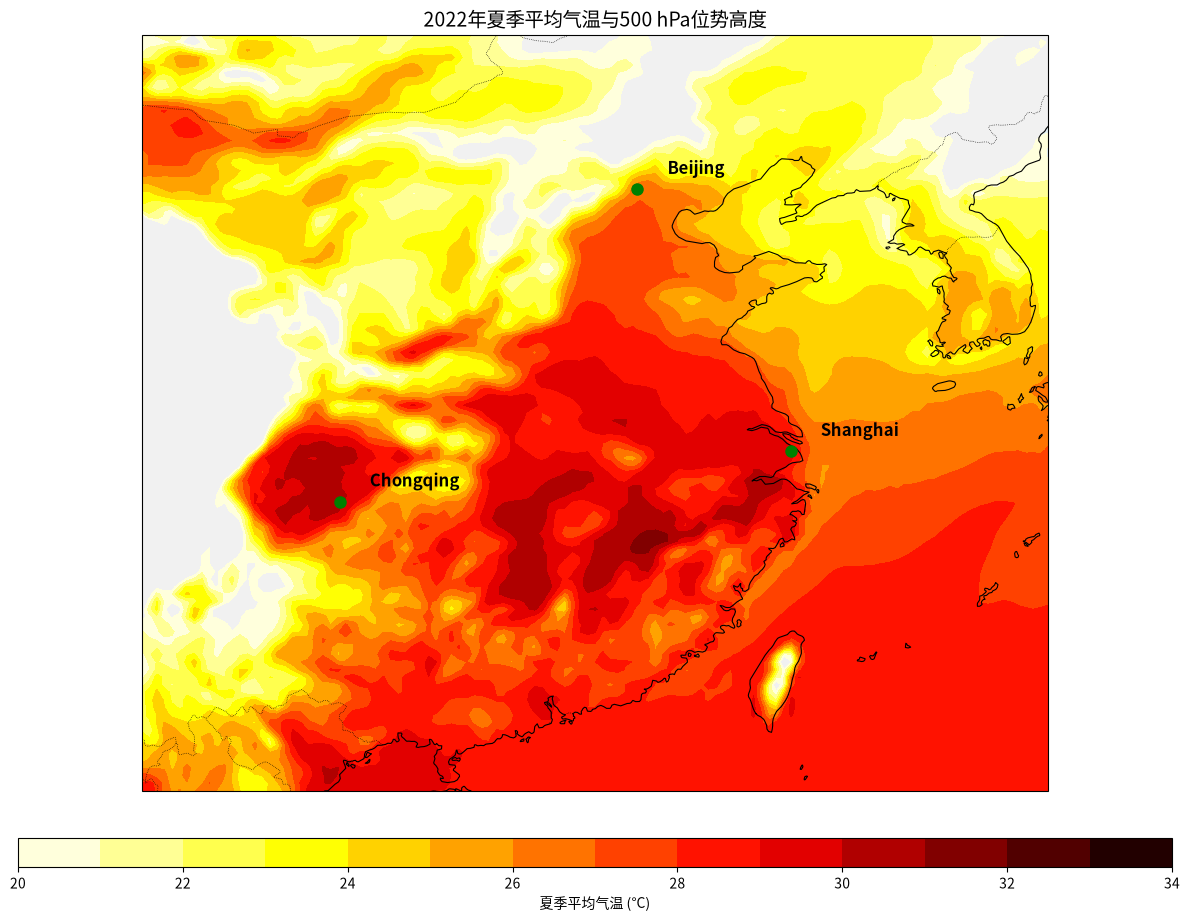

In [10]:
# 创建地图投影
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# 添加地图要素
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)

# 设置地图范围（聚焦中国东部）
ax.set_extent([100, 130, 20, 45], crs=ccrs.PlateCarree())

# 绘制气温填色图
im = ax.contourf(
    t2m_summer_mean.longitude, t2m_summer_mean.latitude,
    t2m_summer_mean,
    levels=np.arange(20, 35, 1),
    cmap='hot_r',
    transform=ccrs.PlateCarree()
)
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, aspect=40)
cbar.set_label('夏季平均气温 (°C)')

# 叠加500 hPa位势高度等值线
contour = ax.contour(
    z500_summer_mean.longitude, z500_summer_mean.latitude,
    z500_summer_mean,
    levels=np.arange(570, 600, 2),
    colors='blue',
    linewidths=1.5,
    transform=ccrs.PlateCarree()
)
ax.clabel(contour, inline=True, fontsize=10, fmt='%d')

# 标注城市
for city, (lat, lon) in cities.items():
    ax.plot(lon, lat, 'go', markersize=8, transform=ccrs.PlateCarree())
    ax.text(lon+1, lat+0.5, city, transform=ccrs.PlateCarree(), 
            fontsize=12, fontweight='bold')

ax.set_title('2022年夏季平均气温与500 hPa位势高度', fontsize=14)
plt.tight_layout()
plt.savefig('summer_analysis.png', dpi=300)
plt.show()

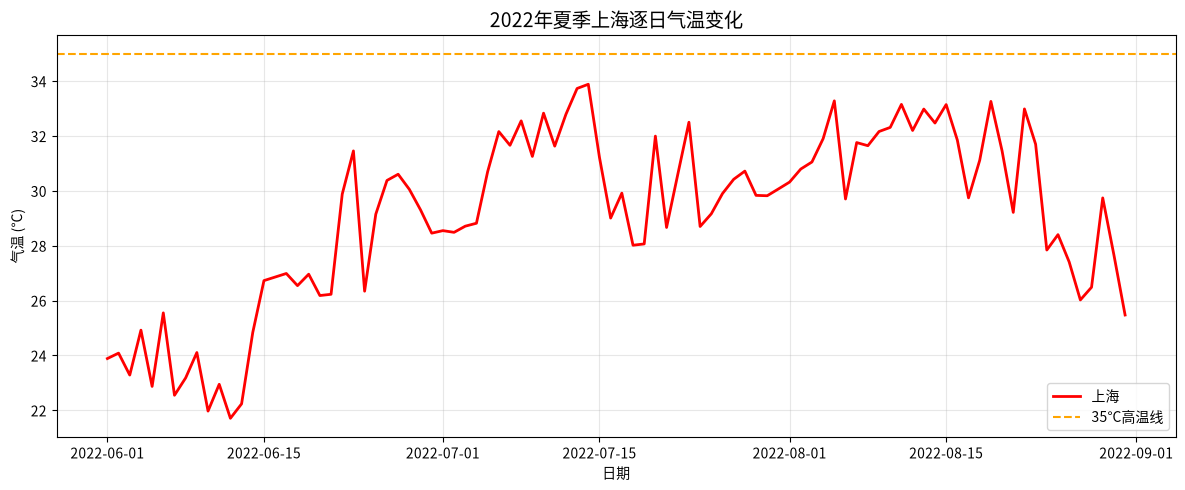

上海夏季高温天数（>35°C）: 0 天


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(shanghai_series.index, shanghai_series.values, 
        'r-', linewidth=2, label='上海')

# 添加35°C高温线
ax.axhline(y=35, color='orange', linestyle='--', linewidth=1.5, label='35°C高温线')

# 标记超过35°C的日期
hot_days = shanghai_series[shanghai_series > 35]
ax.scatter(hot_days.index, hot_days.values, color='red', s=50, zorder=5)

ax.set_xlabel('日期')
ax.set_ylabel('气温 (°C)')
ax.set_title('2022年夏季上海逐日气温变化', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('shanghai_temp_series.png', dpi=300)
plt.show()

# 统计高温天数
print(f"上海夏季高温天数（>35°C）: {len(hot_days)} 天")